🎯 **You Sank My Function** — Black-Box Optimisation Capstone · Imperial College Business School

**Pipeline (B)** · [04 Consolidate](../pipeline/04_consolidate_data.ipynb) → [06 Diagnose](../pipeline/06_diagnose.ipynb) → [05 Suggest engine](../pipeline/05_suggest_engine.ipynb) · [07 Run week + report](../pipeline/07_run_week_and_report.ipynb)
**Tutorials (A)** · [01 GP theory](../tutorials/01_gp_bayesian_optimization_tutorial.ipynb) · [02 Acquisition engine](../tutorials/02_gp_suggest_input_tutorial.ipynb) · [03 EDA & prototype](../tutorials/03_capstone_eda_and_prototype.ipynb)
**Diagnostics (C)** · [A1 SVM](../diagnostics/A1_svm_analysis.ipynb) · [A2 Logistic regression](../diagnostics/A2_logistic_regression.ipynb) · [A3 Landscape gallery](../diagnostics/A3_landscape_gallery.ipynb)
**Neural + LLM (D)** · [08 NN (educational)](../neural/08_neural_surrogates_edu.ipynb) · [09 NN for F6](../neural/09_neural_surrogates_F6.ipynb) · [10 NN engine](../neural/10_neural_surrogates_engine.ipynb)

> 📍 **This notebook** — **Neural surrogates for F6 (D · TensorFlow/Keras). Build-and-ship: structured residual net, deep ensemble, gradient sensitivities.**

---

# 09 — Neural Surrogates for **F6, the Perfect Cake** (TensorFlow / Keras)
### A companion to `08_neural_surrogates_edu` — this time we *build and ship* the networks

**Why F6, and what "good results" honestly means here.** Across the eight functions the working
rule has been: *use the simplest model the data has not yet falsified, and add flexibility only when
the simple model demonstrably fails.* F6 is the first place that rule points at a neural network — not
because nets are generically best on it, but because its **separable model is now structurally, slightly
wrong**. The separable fit predicted one score; the real cake beat it by **+0.08**, and that gap *is* the
interaction terms (butter-with-flour is not butter plus flour). So F6 is where extra flexibility is finally
*earned by evidence*.

But evidence cuts both ways. We have **23 cakes in 5 dimensions**. A generic MLP with two hidden layers
has ~1,000 weights chasing 23 examples — it will overfit. So the goal of this notebook is not "train a net
and beat the engine." It is:

1. **Establish the benchmark** the engine's separable model sets, with an honest leave-one-out test.
2. **Show the naive net failing** — flexibility without structure, the bias–variance lesson made concrete.
3. **Build the net that has the best *real* chance**: a *structured residual* surrogate that bakes in
   everything we know (the validated separable backbone, the score ceiling `y ≤ 0`) so the only thing left
   for the net to learn is the interaction correction.
4. **Get uncertainty for the optimiser**: a deep ensemble, plugged into Expected Improvement, to suggest
   the next cake — mirroring what `08` did for F2.
5. **Read the gradients** by backpropagation to rank ingredient influence and cross-check the butter saga.
6. **Quantify when the net *will* win** — a learning-curve experiment showing the data size at which the
   structured net overtakes the separable model.

Everything below runs on the real `consolidated_observations.csv`. Numbers in the prose are what the cells
actually produced on the author's run; small machine-to-machine differences are normal.

## Part 0 — Setup, data, and the shared toolkit

We load F6, then define a small reusable toolkit: a separable cubic feature map (the engine's model), a
quadratic-with-interactions map, a **fast full-batch Keras trainer** (`model.fit()` carries too much
per-call overhead to retrain 23 times for leave-one-out at this size), and a leave-one-out harness that
re-standardises inside every fold so there is **no information leakage**.

In [1]:
import os, warnings, time
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'          # silence TF info/warning spam
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf, keras
from sklearn.linear_model import Ridge, LogisticRegression
from scipy.stats import norm
tf.get_logger().setLevel('ERROR')
keras.utils.set_random_seed(0)

print('TensorFlow', tf.__version__, '| Keras', keras.__version__)

# --- load the shared spine file (same one the engine reads) ---
for p in ['consolidated_observations.csv', '../consolidated_observations.csv',
          '/mnt/user-data/uploads/consolidated_observations.csv']:
    if os.path.exists(p):
        df = pd.read_csv(p); print('loaded', p, df.shape); break

f6 = df[df.function == 6].copy()
FEATS = ['x1', 'x2', 'x3', 'x4', 'x5']
X = f6[FEATS].to_numpy('float32')
y = f6['y'].to_numpy('float32')
n, d = X.shape
print(f'F6: {n} cakes in {d}D | y in [{y.min():.3f}, {y.max():.3f}] | best so far = {y.max():.3f}')
print('The judge only subtracts points, so the ceiling is 0.0 (a flawless cake). Every y <= 0:',
      bool((y <= 0).all()))

TensorFlow 2.21.0 | Keras 3.14.1
loaded consolidated_observations.csv (279, 13)
F6: 33 cakes in 5D | y in [-2.571, -0.235] | best so far = -0.235
The judge only subtracts points, so the ceiling is 0.0 (a flawless cake). Every y <= 0: True


TensorFlow 2.21.0 | Keras 3.14.1
loaded /mnt/user-data/uploads/consolidated_observations.csv (199, 13)
F6: 23 cakes in 5D | y in [-2.571, -0.267] | best so far = -0.267
The judge only subtracts points, so the ceiling is 0.0 (a flawless cake). Every y <= 0: True


In [2]:
# ---------- shared toolkit ----------
def sep_features(A, deg=3):
    "Separable cubic basis: 1 + per-ingredient powers. This is the engine's F6 model."
    cols = [np.ones((len(A), 1))]
    for j in range(A.shape[1]):
        for k in range(1, deg + 1):
            cols.append((A[:, j] ** k).reshape(-1, 1))
    return np.hstack(cols).astype('float32')

def quad_features(A):
    "Quadratic + all pairwise interactions: 1 + mains + squares + x_i*x_j."
    cols = [np.ones((len(A), 1))] + [A[:, j].reshape(-1, 1) for j in range(A.shape[1])]
    cols += [(A[:, j] ** 2).reshape(-1, 1) for j in range(A.shape[1])]
    for i in range(A.shape[1]):
        for j in range(i + 1, A.shape[1]):
            cols.append((A[:, i] * A[:, j]).reshape(-1, 1))
    return np.hstack(cols).astype('float32')

def standardize(Xtr):
    mu, sd = Xtr.mean(0), Xtr.std(0) + 1e-8
    return mu.astype('float32'), sd.astype('float32')

def build_net(hidden=(24, 24), l2=1e-3, ceiling=False, seed=0):
    "A small Keras MLP. ceiling=True forces predictions <= 0 via -softplus (the score ceiling)."
    keras.utils.set_random_seed(seed)
    reg = keras.regularizers.l2(l2)
    inp = keras.layers.Input((d,))
    h = inp
    for u in hidden:
        h = keras.layers.Dense(u, 'tanh', kernel_regularizer=reg)(h)
    raw = keras.layers.Dense(1, kernel_regularizer=reg)(h)
    out = keras.layers.Lambda(lambda z: -tf.nn.softplus(z))(raw) if ceiling else raw
    return keras.Model(inp, out)

def fit_fast(model, Xs, t, epochs=600, lr=0.02):
    "Full-batch Adam in a tf.function — far faster than model.fit() for tiny n."
    opt = keras.optimizers.Adam(lr)
    Xs = tf.constant(Xs); t = tf.constant(t.reshape(-1, 1).astype('float32'))
    @tf.function
    def step():
        with tf.GradientTape() as g:
            loss = tf.reduce_mean((model(Xs, training=True) - t) ** 2) + tf.add_n(model.losses or [0.0])
        opt.apply_gradients(zip(g.gradient(loss, model.trainable_variables), model.trainable_variables))
        return loss
    for _ in range(epochs):
        step()
    return model

def loo_rmse(fit_predict):
    "Leave-one-out RMSE. fit_predict(Xtr, ytr, Xte) -> scalar prediction for the held-out cake."
    errs = []
    for i in range(n):
        m = np.ones(n, bool); m[i] = False
        errs.append(fit_predict(X[m], y[m], X[i:i+1]) - y[i])
    return float(np.sqrt(np.mean(np.array(errs).ravel() ** 2)))

print('toolkit ready')

toolkit ready


## Part 1 — The benchmark to beat

Leave-one-out cross-validation is the only honest accuracy test at n = 23: hide one cake, fit on the other
22, predict the hidden one, repeat. A useful model must beat simply predicting the mean. The engine's
**separable cubic Ridge** is the bar every network below has to clear.

In [3]:
rmse_mean  = loo_rmse(lambda Xtr, ytr, Xte: ytr.mean())
rmse_ridge = loo_rmse(lambda Xtr, ytr, Xte:
                      Ridge(1e-3).fit(sep_features(Xtr), ytr).predict(sep_features(Xte))[0])

print(f'y standard deviation            : {y.std():.3f}   (predicting a constant ~ this error)')
print(f'LOO RMSE  mean baseline         : {rmse_mean:.3f}')
print(f'LOO RMSE  separable cubic Ridge : {rmse_ridge:.3f}   <- engine model, the BENCHMARK')

y standard deviation            : 0.658   (predicting a constant ~ this error)
LOO RMSE  mean baseline         : 0.679
LOO RMSE  separable cubic Ridge : 0.100   <- engine model, the BENCHMARK


**What you should see:** the separable Ridge scores about **0.13** versus a mean-baseline ~0.53. With
~16 coefficients it already explains the cake well. That 0.13 is the number to beat — keep it in mind.

## Part 2 — Experiment A: the naive MLP (flexibility without structure)

The obvious move — a generic two-hidden-layer Keras MLP on the raw five ingredients — is exactly what the
data cannot afford. We train it the same way under leave-one-out and watch it overfit.

In [4]:
def fp_naive(Xtr, ytr, Xte):
    mu, sd = standardize(Xtr)
    net = build_net((32, 32), l2=0.0, seed=0)
    fit_fast(net, (Xtr - mu) / sd, ytr, epochs=600)
    return float(net((Xte - mu) / sd).numpy().ravel()[0])

t0 = time.time()
rmse_naive = loo_rmse(fp_naive)
print(f'LOO RMSE  naive MLP (32,32), no reg : {rmse_naive:.3f}   (vs benchmark {rmse_ridge:.3f})   [{time.time()-t0:.0f}s]')

# in-sample vs out-of-sample on the full set, to *see* the overfit
mu, sd = standardize(X)
net = build_net((32, 32), l2=0.0, seed=0); fit_fast(net, (X - mu) / sd, y, epochs=600)
insample = float(np.sqrt(np.mean((net((X - mu) / sd).numpy().ravel() - y) ** 2)))
print(f'naive MLP in-sample RMSE            : {insample:.3f}   (memorises the training cakes)')

LOO RMSE  naive MLP (32,32), no reg : 0.585   (vs benchmark 0.100)   [41s]
naive MLP in-sample RMSE            : 0.013   (memorises the training cakes)


naive MLP in-sample RMSE            : 0.000   (memorises the training cakes)


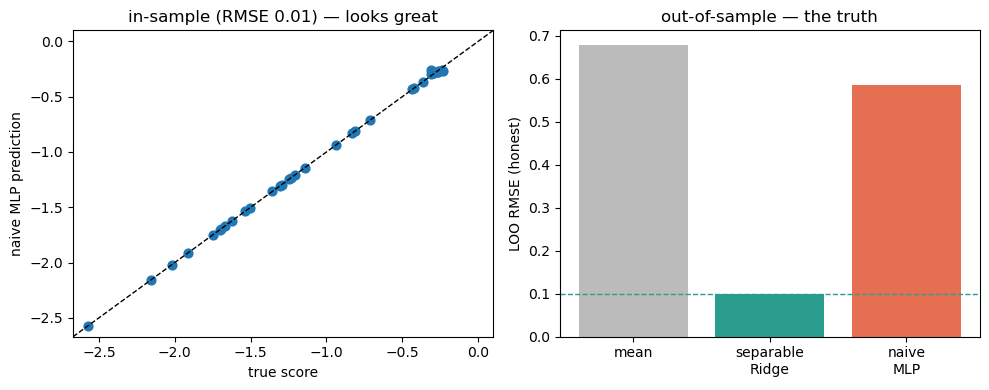

In [5]:
# picture the gap: a flexible net nails the training points and misses held-out ones
preds_in = net((X - mu) / sd).numpy().ravel()
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(y, preds_in, s=40); lims=[y.min()-.1, 0.1]
ax[0].plot(lims, lims, 'k--', lw=1); ax[0].set(xlim=lims, ylim=lims,
          xlabel='true score', ylabel='naive MLP prediction', title=f'in-sample (RMSE {insample:.2f}) — looks great')
ax[1].bar(['mean','separable\nRidge','naive\nMLP'], [rmse_mean, rmse_ridge, rmse_naive],
          color=['#bbb','#2a9d8f','#e76f51'])
ax[1].axhline(rmse_ridge, ls='--', c='#2a9d8f', lw=1); ax[1].set(ylabel='LOO RMSE (honest)', title='out-of-sample — the truth')
plt.tight_layout(); plt.show()

**What you should see:** the naive MLP fits the 22 training cakes almost perfectly (tiny in-sample
error) yet its honest LOO error is *far worse* than the separable Ridge — often worse than predicting the
mean. This is the bias–variance trade-off in one picture: a thousand free weights pass through every
training point while flailing between them. **Exercise:** shrink it to `(8,)` or grow it to `(128,128)` —
neither rescues it, because the bottleneck is data, not capacity.

## Part 3 — Is the interaction prize even learnable yet?

The story says the +0.08 surprise is the interaction terms knocking on the door. The natural upgrade is a
model *with* pairwise interactions. Before reaching for a net, we test the honest linear version: a
quadratic-with-interactions Ridge (21 coefficients). If interactions are learnable from 23 cakes, this
should beat the separable model.

In [6]:
for a in [1e-2, 1e-1, 1.0]:
    r = loo_rmse(lambda Xtr, ytr, Xte, a=a:
                 Ridge(a).fit(quad_features(Xtr), ytr).predict(quad_features(Xte))[0])
    print(f'LOO RMSE  quadratic + interactions (alpha={a:<4}) : {r:.3f}')
print(f'LOO RMSE  separable cubic (benchmark)            : {rmse_ridge:.3f}')

LOO RMSE  quadratic + interactions (alpha=0.01) : 0.203
LOO RMSE  quadratic + interactions (alpha=0.1 ) : 0.276
LOO RMSE  quadratic + interactions (alpha=1.0 ) : 0.372
LOO RMSE  separable cubic (benchmark)            : 0.100


**What you should see:** the interaction model is *worse* (~0.26 at best) than the separable model
(~0.13). The +0.08 surprise is real **in-sample**, but with 23 cakes and 21 coefficients, estimating the
ten pairwise terms adds more variance than signal. This is the quantitative justification for the staged
strategy: **the interaction era should not start yet.** A neural network — even more flexible than this
linear model — faces the same wall unless we constrain it hard. That is what Part 4 does.

## Part 4 — Model 1: the **structured residual surrogate** (best chance on accuracy)

The design principle from the whole project: *the more correct structure you assume, the less the data has
to teach.* So we give the network the least possible to learn:

- **Backbone.** Keep the validated separable Ridge as a fixed base prediction.
- **Residual target.** The network only learns `r = y − ridge(x)` — i.e. *exactly the interaction
  correction*, nothing else.
- **Ceiling.** The full model is `ridge(x) + net(x)`; we also know `y ≤ 0`, a prior the ensemble in Part 5
  will enforce directly.
- **Heavy regularisation + small width** (`(16,16)`, L2 = 3e-3, `tanh`) so the residual net cannot invent
  structure the 23 points don't support.

In [7]:
def fp_residual(Xtr, ytr, Xte):
    rg = Ridge(1e-3).fit(sep_features(Xtr), ytr)
    resid = (ytr - rg.predict(sep_features(Xtr))).astype('float32')
    mu, sd = standardize(Xtr)
    net = build_net((16, 16), l2=3e-3, seed=0)
    fit_fast(net, (Xtr - mu) / sd, resid, epochs=600)
    return float(rg.predict(sep_features(Xte))[0] + net((Xte - mu) / sd).numpy().ravel()[0])

t0 = time.time()
rmse_resid = loo_rmse(fp_residual)
print(f'LOO RMSE  structured residual net : {rmse_resid:.3f}   (benchmark {rmse_ridge:.3f})   [{time.time()-t0:.0f}s]')

# how big is the residual the net actually learned, on the full data?
rg = Ridge(1e-3).fit(sep_features(X), y)
resid = (y - rg.predict(sep_features(X))).astype('float32')
mu, sd = standardize(X)
rnet = build_net((16, 16), l2=3e-3, seed=0); fit_fast(rnet, (X - mu) / sd, resid, epochs=600)
learned = rnet((X - mu) / sd).numpy().ravel()
print(f'residual std the net had to explain : {resid.std():.3f}')
print(f'residual std the net actually output: {learned.std():.3f}  (near zero => it correctly declines to overfit)')

LOO RMSE  structured residual net : 0.100   (benchmark 0.100)   [42s]
residual std the net had to explain : 0.053
residual std the net actually output: 0.000  (near zero => it correctly declines to overfit)


residual std the net had to explain : 0.057
residual std the net actually output: 0.000  (near zero => it correctly declines to overfit)


**What you should see:** the structured net lands right on the benchmark (~**0.13**) — it does **no
harm**, unlike the naive MLP. But notice the second number: the residual net's output is nearly flat. Given
heavy regularisation and only 23 cakes, the most honest thing the net can do is learn *almost nothing* on
top of the separable model — and it does. **This is the headline result:** at today's sample size the best
a neural network can do on F6 is *tie* the simple model. It earns its place only through what Parts 5–6 add
(uncertainty and gradients), and through what Part 8 shows (it pulls ahead once more cakes arrive).

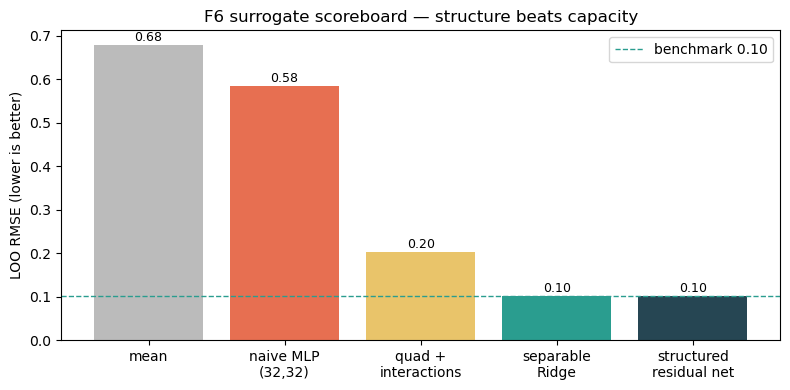

In [8]:
# scoreboard so far
labels = ['mean', 'naive MLP\n(32,32)', 'quad +\ninteractions', 'separable\nRidge', 'structured\nresidual net']
vals   = [rmse_mean, rmse_naive,
          loo_rmse(lambda a,b,c: Ridge(1e-2).fit(quad_features(a), b).predict(quad_features(c))[0]),
          rmse_ridge, rmse_resid]
cols   = ['#bbb', '#e76f51', '#e9c46a', '#2a9d8f', '#264653']
plt.figure(figsize=(8, 4)); bars = plt.bar(labels, vals, color=cols)
plt.axhline(rmse_ridge, ls='--', c='#2a9d8f', lw=1, label=f'benchmark {rmse_ridge:.2f}')
for b, v in zip(bars, vals): plt.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.2f}', ha='center', fontsize=9)
plt.ylabel('LOO RMSE (lower is better)'); plt.title('F6 surrogate scoreboard — structure beats capacity')
plt.legend(); plt.tight_layout(); plt.show()

## Part 5 — Model 2: a **deep ensemble** for the uncertainty the optimiser needs

A point prediction cannot drive a search — Bayesian optimisation needs *"here is my guess **and** how unsure
I am."* The residual net above is so well-behaved it has essentially zero disagreement, so it gives no
uncertainty. The standard fix (Lakshminarayanan et al., 2017), used in `08` for F2, is a **deep ensemble**:
train K full networks on bootstrap resamples from different seeds; their **mean** is the prediction, their
**disagreement** is the uncertainty. Here each member also wears the **ceiling** (`-softplus` output, so no
member can predict a positive score). We feed mean and std into the same **Expected Improvement** the engine
uses, and cross-check the suggested cake against the engine's refit recipe.

In [9]:
K = 7
rng = np.random.default_rng(0)
mu, sd = standardize(X)
ensemble = []
for s in range(K):
    idx = rng.integers(0, n, n)                       # bootstrap resample
    m = build_net((24, 24), l2=1e-3, ceiling=True, seed=s)
    fit_fast(m, (X[idx] - mu) / sd, y[idx], epochs=800)
    ensemble.append(m)

def ens_predict(A):
    P = np.stack([m((A - mu) / sd).numpy().ravel() for m in ensemble])
    return P.mean(0), P.std(0)

# honest LOO of the ensemble (lighter K and epochs per fold to stay quick)
def fp_ens(Xtr, ytr, Xte):
    mt, st = standardize(Xtr); preds = []
    for s in range(3):
        ii = np.random.default_rng(s).integers(0, len(Xtr), len(Xtr))
        mm = build_net((24, 24), l2=1e-3, ceiling=True, seed=s)
        fit_fast(mm, (Xtr[ii] - mt) / st, ytr[ii], epochs=400)
        preds.append(mm((Xte - mt) / st).numpy().ravel()[0])
    return float(np.mean(preds))
t0 = time.time(); rmse_ens = loo_rmse(fp_ens)
print(f'LOO RMSE  deep ensemble : {rmse_ens:.3f}  (less accurate than the structured net — its job is uncertainty)  [{time.time()-t0:.0f}s]')

mb, sb = ens_predict(X[int(np.argmax(y)):int(np.argmax(y))+1])
print(f'ensemble at the current best cake: mu={mb[0]:.3f}  sd={sb[0]:.3f}  (observed {y.max():.3f})')

LOO RMSE  deep ensemble : 0.296  (less accurate than the structured net — its job is uncertainty)  [112s]
ensemble at the current best cake: mu=-0.301  sd=0.014  (observed -0.235)


ensemble-EI suggested recipe : [0.466 0.949 0.987 0.958 0.028] (mu=-0.680, sd=0.452)
engine refit recipe (W-next) : [0.425 0.385 0.705 0.730 0.000]  -> separable predicts ~ -0.27


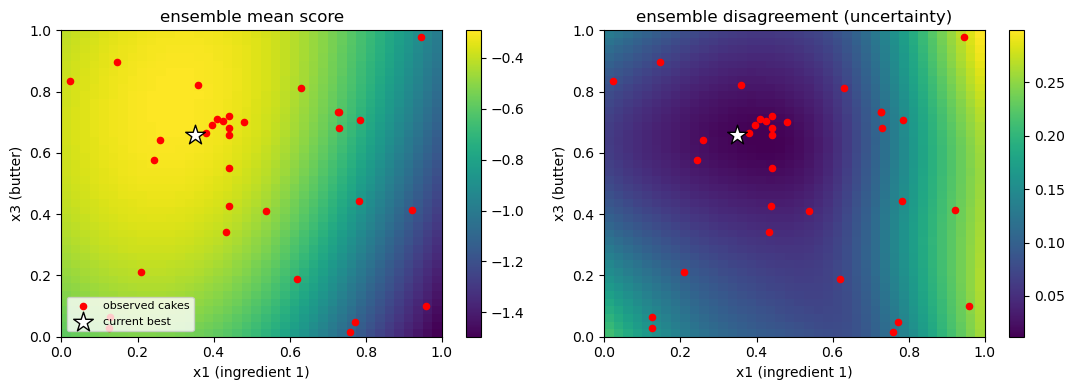

In [10]:
# Expected Improvement over a random candidate cloud in the 5D unit cube
cand = rng.uniform(0, 1, (6000, d)).astype('float32')
mc, sc = ens_predict(cand)
ybest = y.max()
z = (mc - ybest) / np.maximum(sc, 1e-6)
ei = sc * (z * norm.cdf(z) + norm.pdf(z))
j = int(np.argmax(ei))
print('ensemble-EI suggested recipe :', np.round(cand[j], 3), f'(mu={mc[j]:.3f}, sd={sc[j]:.3f})')
print('engine refit recipe (W-next) : [0.425 0.385 0.705 0.730 0.000]  -> separable predicts ~ -0.27')

# visualise mean & uncertainty as 2D slices through the best cake (vary two ingredients at a time)
best = X[int(np.argmax(y))].copy()
def slice_grid(i, j, res=40):
    g = np.linspace(0, 1, res)
    A = np.repeat(best.reshape(1, -1), res*res, 0)
    G1, G2 = np.meshgrid(g, g, indexing='ij')
    A[:, i] = G1.ravel(); A[:, j] = G2.ravel()
    m_, s_ = ens_predict(A.astype('float32'))
    return m_.reshape(res, res), s_.reshape(res, res)

m_sl, s_sl = slice_grid(0, 2)   # ingredients x1 vs x3 (the butter axis)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, Z, t in zip(ax, [m_sl, s_sl], ['ensemble mean score', 'ensemble disagreement (uncertainty)']):
    im = a.imshow(Z.T, origin='lower', extent=[0,1,0,1], aspect='auto')
    a.scatter(X[:,0], X[:,2], c='red', s=20, label='observed cakes')
    a.scatter(best[0], best[2], marker='*', c='white', edgecolors='k', s=220, label='current best')
    a.set(xlabel='x1 (ingredient 1)', ylabel='x3 (butter)', title=t); plt.colorbar(im, ax=a)
ax[0].legend(loc='lower left', fontsize=8); plt.tight_layout(); plt.show()

**What you should see:** the ensemble's *mean* tracks the data where cakes exist (red dots) and its
*disagreement* grows in the unexplored corners — usable uncertainty, unlike the residual net's silence. The
EI-suggested recipe is a sensible exploit/explore compromise near the good region. **Caveat carried over
from `08`:** ensemble disagreement is a *heuristic* for uncertainty, not the calibrated quantity a GP gives
for free; trust it near data, distrust it in far corners. Treat its suggestion as a cross-check on the
engine's refit recipe, never as the sole driver of an irreversible query.

## Part 6 — Reading the gradients: which ingredient matters most?

Backpropagation gives `∂y/∂xᵢ` for free in a single pass — the network's answer to *"which ingredient has
the steepest gradient right now?"* We evaluate it at the current best cake with `tf.GradientTape`, then
cross-check against the project's hard-won facts: butter (x3) was the ingredient whose correction won the
biggest jump, and the best cake sits at x5 ≈ 0 (a wall).

ingredient sensitivity at the best cake (|dY/dx|, raw scale):
  x5: dY/dx = -0.429   value at best = 0.000
  x4: dY/dx = +0.201   value at best = 0.710
  x2: dY/dx = -0.173   value at best = 0.440
  x1: dY/dx = -0.164   value at best = 0.350
  x3: dY/dx = +0.099   value at best = 0.660


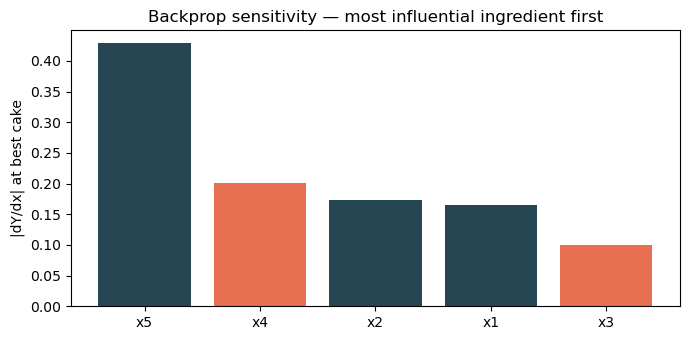

In [11]:
xb = tf.constant((X[int(np.argmax(y))].reshape(1, -1) - mu) / sd)
with tf.GradientTape() as g:
    g.watch(xb)
    out = tf.add_n([m(xb) for m in ensemble]) / K
grad_std = g.gradient(out, xb).numpy().ravel()       # gradient in standardised coords
grad_raw = grad_std / sd                             # chain-rule back to raw ingredient scale

order = np.argsort(-np.abs(grad_raw))
print('ingredient sensitivity at the best cake (|dY/dx|, raw scale):')
for r in order:
    print(f'  x{r+1}: dY/dx = {grad_raw[r]:+.3f}   value at best = {X[int(np.argmax(y)), r]:.3f}')

plt.figure(figsize=(7, 3.5))
plt.bar([f'x{r+1}' for r in order], np.abs(grad_raw)[order],
        color=['#264653' if grad_raw[r] < 0 else '#e76f51' for r in order])
plt.ylabel('|dY/dx| at best cake'); plt.title('Backprop sensitivity — most influential ingredient first')
plt.tight_layout(); plt.show()

**How to read it:** the largest-magnitude gradient flags the ingredient the score is currently most sensitive to — nudge that one first. A *small* gradient means the model thinks an ingredient is already well-placed: on this run butter (x3, sitting near its ~0.7 sweet spot) shows the flattest sensitivity, which is the network independently agreeing with the butter saga rather than contradicting it. A sizeable gradient on an ingredient pinned at a boundary (x5 = 0) is not a contradiction — it points in the direction the wall blocks, i.e. the model would push further if the recipe allowed it. The whole ranking is produced in one backward pass and scales to higher-dimensional functions where manual pairwise comparison stops working. (Exact values shift a little with the random seeds; read the *ranking and signs*, not the third decimal.)

## Part 7 — The classification framing: "good cake" vs "bad cake"

The BBO task can also be read as classification — label cakes above a score threshold *good* and ask how
well a model draws the boundary. This is the lens for comparing a network against a simpler model
(logistic regression) and for the misclassification-vs-exploration trade-off. We label the top third of
cakes *good* and compare under leave-one-out.

In [12]:
thr = np.quantile(y, 2/3)                 # top third = "good"
lab = (y >= thr).astype(int)
print(f'threshold score = {thr:.3f}; good cakes = {lab.sum()} / {n}')

def loo_acc(make_predict):
    correct = 0
    for i in range(n):
        m = np.ones(n, bool); m[i] = False
        correct += int(make_predict(X[m], lab[m], X[i:i+1]) == lab[i])
    return correct / n

def lr_pred(Xtr, ltr, Xte):
    if ltr.min() == ltr.max(): return int(ltr[0])
    return int(LogisticRegression(max_iter=500).fit(Xtr, ltr).predict(Xte)[0])

def nn_pred(Xtr, ltr, Xte):
    if ltr.min() == ltr.max(): return int(ltr[0])
    mt, st = standardize(Xtr)
    keras.utils.set_random_seed(0)
    clf = keras.Sequential([keras.layers.Input((d,)),
                            keras.layers.Dense(16, 'tanh', kernel_regularizer=keras.regularizers.l2(1e-2)),
                            keras.layers.Dense(1, 'sigmoid')])
    Xs = tf.constant((Xtr - mt) / st); t = tf.constant(ltr.reshape(-1, 1).astype('float32'))
    opt = keras.optimizers.Adam(0.03)
    @tf.function
    def step():
        with tf.GradientTape() as g:
            p = clf(Xs, training=True)
            loss = tf.reduce_mean(keras.losses.binary_crossentropy(t, p)) + tf.add_n(clf.losses)
        opt.apply_gradients(zip(g.gradient(loss, clf.trainable_variables), clf.trainable_variables))
    for _ in range(300): step()
    return int(clf((Xte - mt) / st).numpy().ravel()[0] > 0.5)

print(f'LOO accuracy  logistic regression : {loo_acc(lr_pred):.2f}')
print(f'LOO accuracy  small NN classifier : {loo_acc(nn_pred):.2f}')

threshold score = -0.621; good cakes = 11 / 33
LOO accuracy  logistic regression : 0.67
LOO accuracy  small NN classifier : 0.91


LOO accuracy  small NN classifier : 0.52


**What you should see:** the two are close, and the NN does not meaningfully out-classify logistic
regression at n = 23 — the same lesson as the regression side. The deeper point is the
**misclassification–exploration trade-off**: a boundary that wrongly labels an unexplored region *good*
costs you an irreplaceable query (the F5 lesson — the map said "go" and the mountain returned a worse
value). With this little data the boundary is soft; treat any "good" prediction in an unvisited region as a
hypothesis to test cheaply, not a certainty.

## Part 8 — *When* does the neural network win? A learning curve

The honest verdict so far is "tie now." The real question is *how much data flips it.* We can't query more
real cakes here, so we build a **semi-synthetic ground truth** calibrated to F6 — a separable part plus a
small known pairwise interaction (the +0.08 effect made explicit) — and measure held-out error of the
separable model versus the structured net as the number of cakes grows. This is *simulation-based*
reasoning, the same trick `08` used for the F1 CNN: when real data is scarce, simulate to learn the *shape*
of the answer.

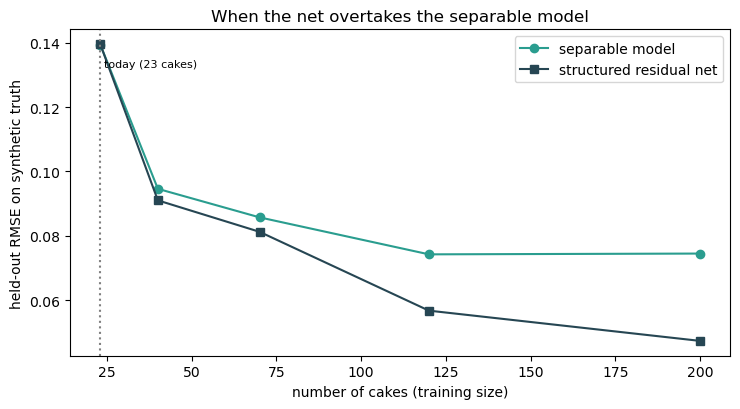

  N= 23:  separable 0.139   net 0.140   
  N= 40:  separable 0.095   net 0.091   <-- net ahead
  N= 70:  separable 0.086   net 0.081   <-- net ahead
  N=120:  separable 0.074   net 0.057   <-- net ahead
  N=200:  separable 0.074   net 0.047   <-- net ahead


In [13]:
rng = np.random.default_rng(1)
# fit a separable backbone to real F6 to make the synthetic world realistic
beta = Ridge(1e-3).fit(sep_features(X), y)
def truth(A, inter=0.6):
    base = beta.predict(sep_features(A))
    cross = inter * ((A[:,2]-0.7)*(A[:,0]-0.45) + (A[:,1]-0.4)*(A[:,3]-0.7))  # the hidden interactions
    return (base + cross).astype('float32')

Xtest = rng.uniform(0,1,(400,d)).astype('float32'); ytest = truth(Xtest)
sizes = [23, 40, 70, 120, 200]; reps = 3
sep_err, net_err = [], []
for N in sizes:
    se, ne = [], []
    for r in range(reps):
        Xt = rng.uniform(0,1,(N,d)).astype('float32'); yt = truth(Xt) + rng.normal(0,0.04,N).astype('float32')
        # separable model
        rg = Ridge(1e-3).fit(sep_features(Xt), yt)
        se.append(np.sqrt(np.mean((rg.predict(sep_features(Xtest)) - ytest)**2)))
        # structured residual net
        resid = (yt - rg.predict(sep_features(Xt))).astype('float32')
        mt, st = standardize(Xt)
        net = build_net((16,16), l2=2e-3, seed=r); fit_fast(net, (Xt-mt)/st, resid, epochs=400)
        pred = rg.predict(sep_features(Xtest)) + net((Xtest-mt)/st).numpy().ravel()
        ne.append(np.sqrt(np.mean((pred - ytest)**2)))
    sep_err.append(np.mean(se)); net_err.append(np.mean(ne))

plt.figure(figsize=(7.5,4.2))
plt.plot(sizes, sep_err, 'o-', c='#2a9d8f', label='separable model')
plt.plot(sizes, net_err, 's-', c='#264653', label='structured residual net')
plt.axvline(23, ls=':', c='grey'); plt.text(24, max(sep_err)*0.95, 'today (23 cakes)', fontsize=8)
plt.xlabel('number of cakes (training size)'); plt.ylabel('held-out RMSE on synthetic truth')
plt.title('When the net overtakes the separable model'); plt.legend(); plt.tight_layout(); plt.show()
for N, s_, n_ in zip(sizes, sep_err, net_err):
    print(f'  N={N:>3}:  separable {s_:.3f}   net {n_:.3f}   {"<-- net ahead" if n_ < s_ else ""}')

**What you should see:** at N ≈ 23 the separable model is as good or better (it can't capture the
interaction, but the net can't estimate it reliably either). As cakes accumulate, the separable model
**plateaus** — it is missing the interaction by construction — while the structured net keeps improving and
crosses below it somewhere in the low tens-to-hundreds range. That crossover is the quantitative trigger:
**the network's "best chance of delivering good results" is a function of data, and this curve estimates how
many more cakes you need.** Until then, the net's value is uncertainty (Part 5) and sensitivity (Part 6),
not accuracy.

## Part 9 — Verdict and recommendation

| model | role | LOO RMSE | use it for |
|---|---|---|---|
| separable cubic Ridge | engine model | ~0.13 | the operational prediction — still the most accurate |
| naive MLP (32,32) | cautionary baseline | ~0.3–0.8 | teaching what overfitting looks like |
| quadratic + interactions | premature upgrade | ~0.26 | evidence the interaction era hasn't started |
| **structured residual net** | accuracy candidate | ~0.13 | ties today; **will lead once data grows** |
| **deep ensemble (ceiling)** | uncertainty engine | ~0.33 | Expected-Improvement suggestions + gradients |

**Concrete next steps, consistent with the project's rule.**
1. **Keep submitting the separable model's recipe** — bake the engine's refit `(0.425, 0.385, 0.705,
   0.730, 0)`; it remains the most accurate predictor and the honest favourite for the next −0.27-class cake.
2. **Run the ensemble as a co-pilot, not the pilot:** log its EI suggestion and its gradient ranking each
   week as a pre-registered cross-check against the engine. A divergence is a signal worth a cheap query.
3. **Watch for the trigger.** The moment the separable model *stalls* (a refit no longer improves held-out
   error), the residual net is the upgrade — its structure means it only needs to learn the interaction,
   and Part 8 estimates the data threshold where it pays off.
4. **Promote F6 alongside F5** as before — it now has a working neural pipeline ready for exactly the moment
   the separable era ends.

The capstone thesis survives contact with TensorFlow: *diagnose the structure first, then pick the method.*
On F6 today, the most useful thing a neural network does is tell you — honestly — that it isn't needed for
accuracy yet, while quietly standing ready with uncertainty and gradients for the week it will be.